In [2]:
import pandas as pd
from sqlalchemy import create_engine

# Database connection
DB_USER = "apple"
DB_PASSWORD = "newStrongPassword123"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "kush"

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

# Extract daily data
daily_df = pd.read_sql("SELECT * FROM daily_stock_data", con=engine, parse_dates=['date'])

# Optional: weekly and monthly
weekly_df = pd.read_sql("SELECT * FROM weekly_stock_summary", con=engine, parse_dates=['date'])
monthly_df = pd.read_sql("SELECT * FROM monthly_stock_summary", con=engine, parse_dates=['date'])


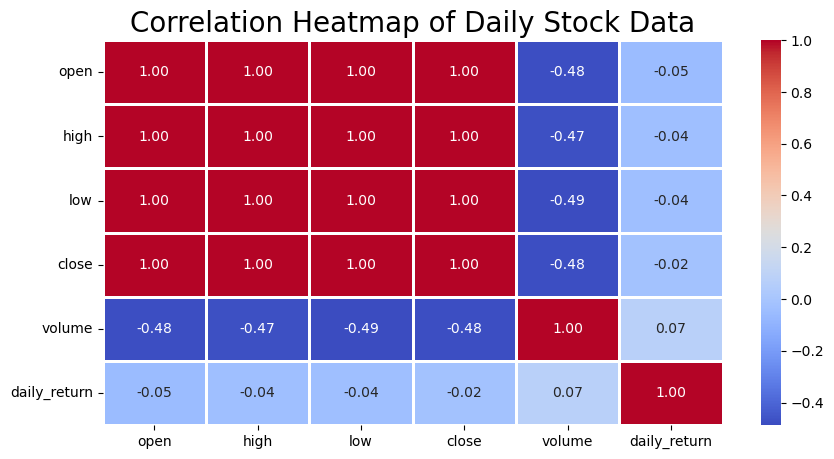

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = daily_df[['open', 'high', 'low', 'close', 'volume', 'daily_return']].corr()

plt.figure(figsize=(10,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title("Correlation Heatmap of Daily Stock Data", fontsize=20)
plt.show()


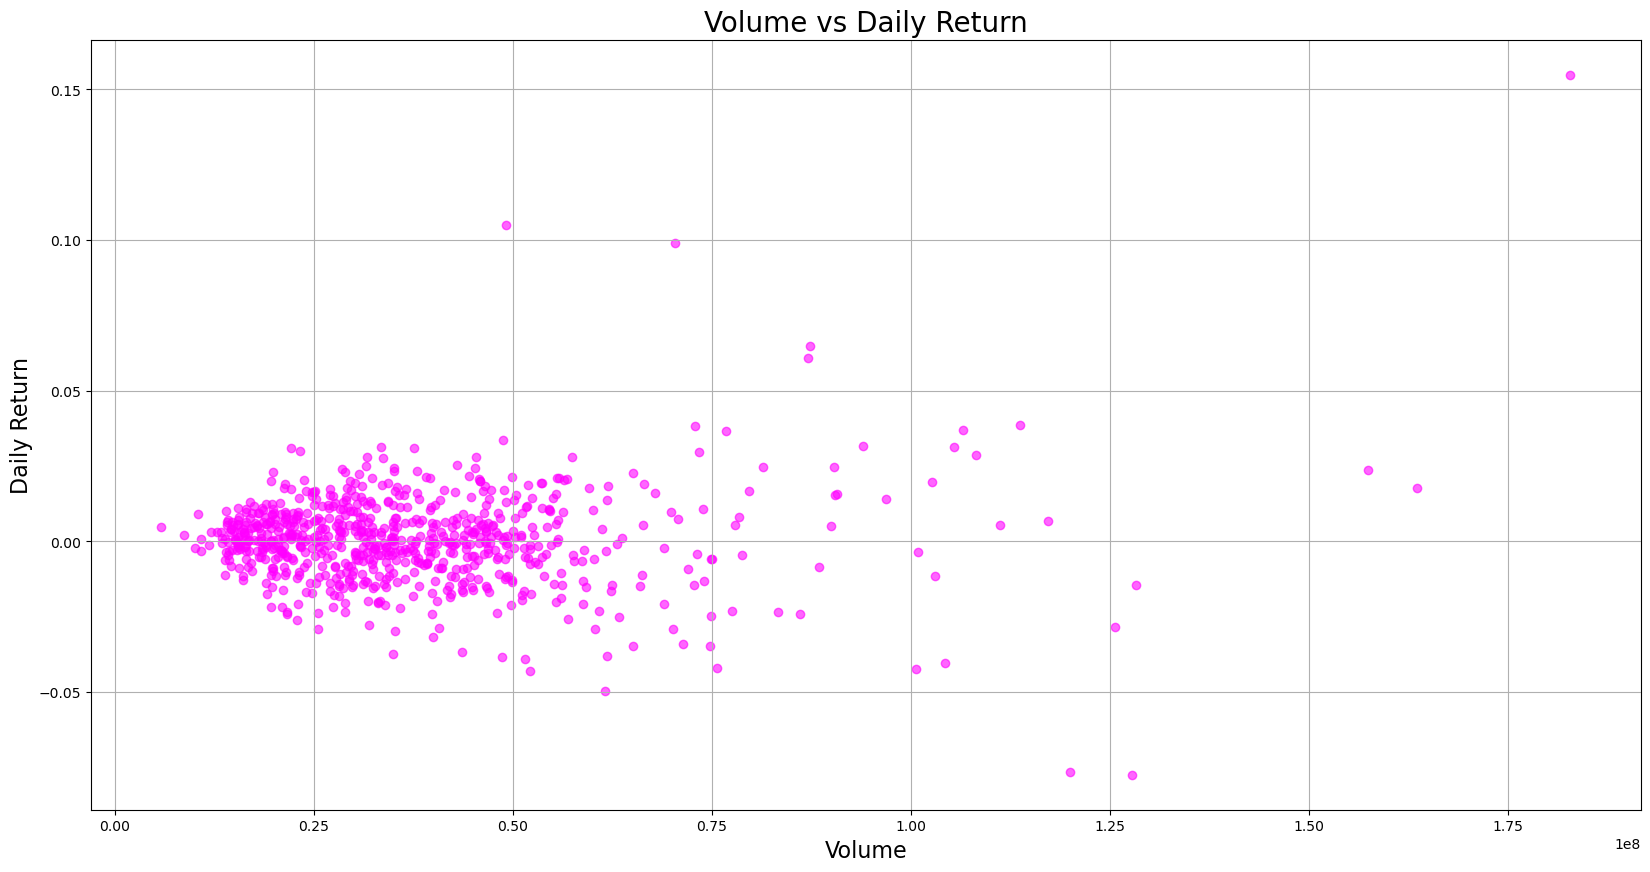

In [8]:
plt.figure(figsize=(20,10))
plt.scatter(daily_df['volume'], daily_df['daily_return'], color='magenta', alpha=0.6)
plt.title("Volume vs Daily Return", fontsize=20)
plt.xlabel("Volume", fontsize=16)
plt.ylabel("Daily Return", fontsize=16)
plt.grid(True)
plt.show()

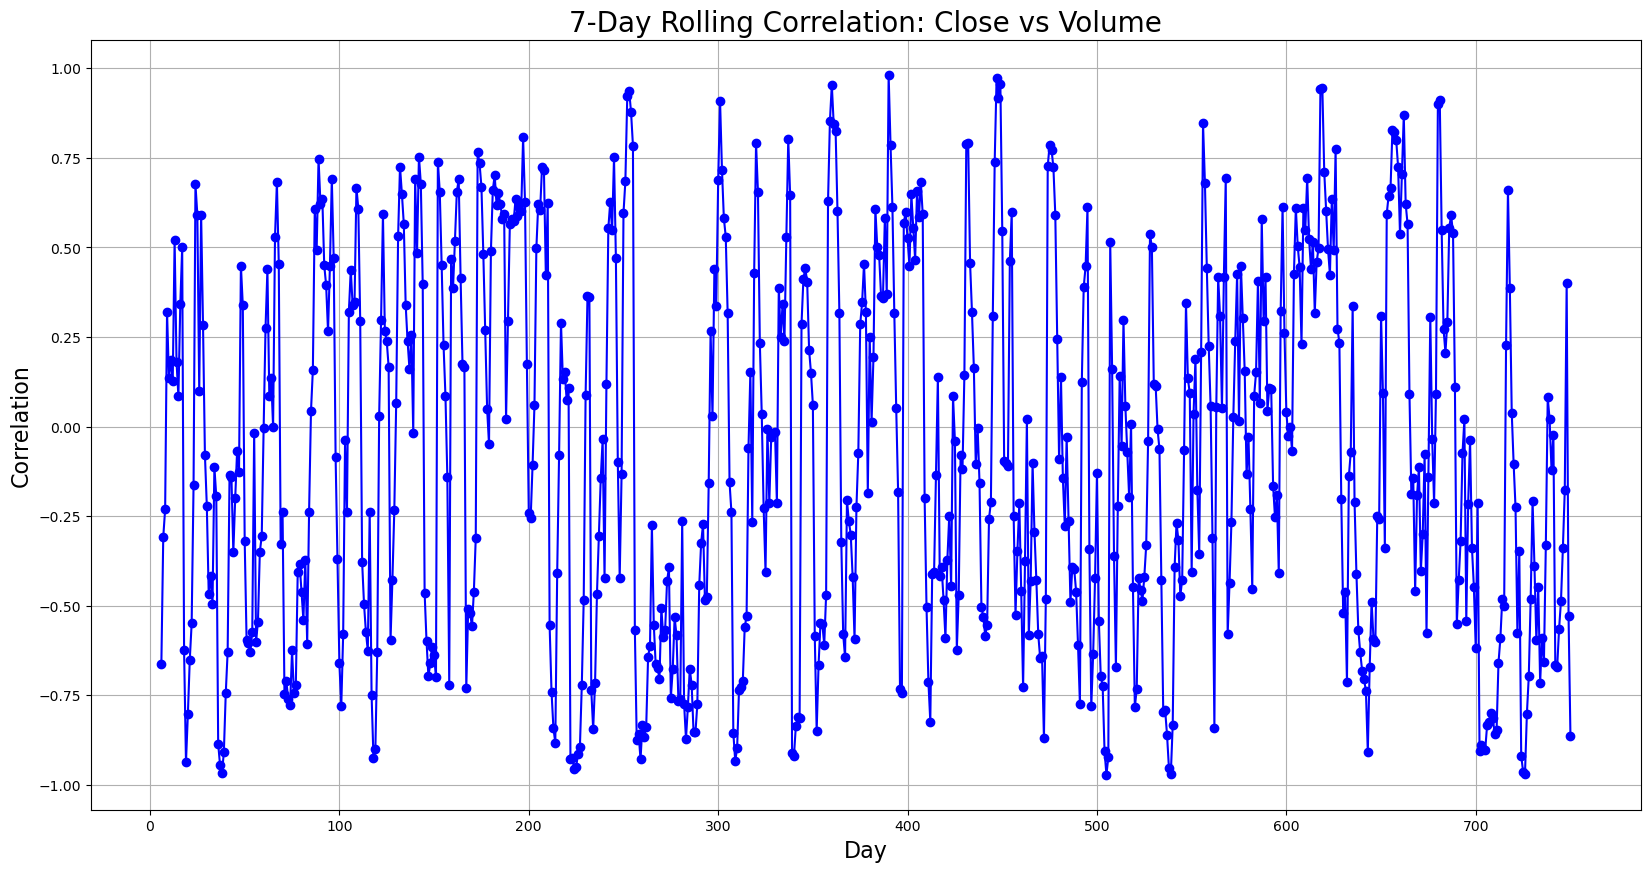

Plot saved as rolling_correlation_close_volume.jpg


<Figure size 640x480 with 0 Axes>

In [14]:
# Compute 7-day rolling correlation
rolling_corr = daily_df['close'].rolling(window=7).corr(daily_df['volume'])

plt.figure(figsize=(20,10))
plt.plot(rolling_corr.index, rolling_corr, color='blue', marker='o')
plt.title("7-Day Rolling Correlation: Close vs Volume", fontsize=20)
plt.xlabel("Day", fontsize=16)
plt.ylabel("Correlation", fontsize=16)
plt.grid(True)
plt.show()

# Save the plot
plt.savefig("rolling_correlation_close_volume.png")
print("Plot saved as rolling_correlation_close_volume.jpg")
